<a href="https://colab.research.google.com/github/khemanth2709/chatbot_intern_codec/blob/main/codectechnologies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartAI Chatbot Using Machine Learning and Deep Learning
**2-Month Artificial Intelligence Internship Project**

## Objective
Develop an intelligent conversational chatbot capable of understanding user questions and generating appropriate responses using Artificial Intelligence. This notebook demonstrates the complete AI pipeline:
- Data Collection & Cleaning
- Text Preprocessing & Feature Engineering
- Machine Learning & Deep Learning Implementation
- Model Evaluation & Performance Comparison
- Interactive Chatbot Inference with Context Memory

In [1]:
!pip install numpy pandas scikit-learn tensorflow matplotlib seaborn nltk joblib -q

In [6]:
import os
import re
import time
import json
import pickle
import joblib
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [7]:
intents_data = {
    "Greetings": {
        "patterns": ["hello", "hi", "hey", "good morning", "good evening", "hi there", "greetings", "howdy"],
        "responses": ["Hello! How can I help you?", "Hi there!", "Greetings! How may I assist you today?"]
    },
    "Farewell": {
        "patterns": ["bye", "goodbye", "see you", "catch you later", "exit", "quit", "good night"],
        "responses": ["Goodbye! Have a great day.", "See you later!", "Take care!"]
    },
    "Artificial Intelligence": {
        "patterns": ["what is ai", "define artificial intelligence", "explain ai", "what does ai mean", "tell me about ai"],
        "responses": ["AI is the simulation of human intelligence in machines.", "Artificial Intelligence enables computers to mimic human behavior."]
    },
    "Machine Learning": {
        "patterns": ["what is ml", "define machine learning", "explain ml", "how does machine learning work"],
        "responses": ["Machine Learning is a subset of AI where systems learn from data.", "ML involves training algorithms to find patterns in data."]
    },
    "Deep Learning": {
        "patterns": ["what is deep learning", "define dl", "explain deep learning", "how is dl different"],
        "responses": ["Deep Learning uses neural networks with many layers.", "DL is a specialized subset of ML based on artificial neural networks."]
    },
    "Python": {
        "patterns": ["what is python", "why use python", "python programming", "tell me about python"],
        "responses": ["Python is a high-level programming language great for AI and data science.", "Python is widely used due to its readability and massive library ecosystem."]
    },
    "Programming": {
        "patterns": ["what is coding", "how to code", "programming definition", "what is software development"],
        "responses": ["Programming is writing instructions for a computer to execute.", "Coding is the process of creating software applications."]
    },
    "Data Science": {
        "patterns": ["what is data science", "define data science", "what does a data scientist do"],
        "responses": ["Data Science involves extracting insights from structured and unstructured data.", "It combines statistics, computer science, and domain knowledge."]
    },
    "College": {
        "patterns": ["what are college hours", "where is the campus", "college location", "how to apply to college"],
        "responses": ["College operates from 9 AM to 5 PM.", "Please visit the official college website for admission details."]
    },
    "Weather": {
        "patterns": ["how is the weather", "is it raining", "weather forecast", "temperature today"],
        "responses": ["I cannot check real-time weather, please look outside!", "I don't have internet access to live weather data."]
    },
    "Time": {
        "patterns": ["what time is it", "current time", "tell me the time"],
        "responses": ["I don't have a clock, but your device should display the current time.", "Please check your system time."]
    },
    "Date": {
        "patterns": ["what is the date", "today's date", "current date"],
        "responses": ["You can check the calendar on your device for today's date."]
    },
    "General Knowledge": {
        "patterns": ["who is the president", "capital of france", "how many continents are there"],
        "responses": ["I am focused on AI and tech, but the capital of France is Paris!", "There are seven continents on Earth."]
    },
    "Motivation": {
        "patterns": ["motivate me", "give me a quote", "i feel sad", "inspire me"],
        "responses": ["You can do this! Keep pushing forward.", "Believe in yourself and all that you are.", "Every expert was once a beginner."]
    },
    "Jokes": {
        "patterns": ["tell me a joke", "make me laugh", "do you know any jokes"],
        "responses": ["Why do programmers prefer dark mode? Because light attracts bugs!", "There are 10 types of people: those who understand binary, and those who don't."]
    },
    "Technology": {
        "patterns": ["what is blockchain", "explain cloud computing", "what is 5g"],
        "responses": ["Technology is constantly evolving. Blockchain is a distributed ledger.", "Cloud computing allows accessing resources over the internet."]
    },
    "Career": {
        "patterns": ["how to get a job", "career advice", "how to become a data scientist"],
        "responses": ["Build a strong portfolio, learn continuously, and network.", "Internships and real-world projects are key to starting your tech career."]
    },
    "Education": {
        "patterns": ["why is education important", "should i study", "learning resources"],
        "responses": ["Education empowers you with knowledge and skills.", "Continuous learning is the best way to grow in any industry."]
    },
    "Help": {
        "patterns": ["help me", "i need assistance", "can you help", "what can you do"],
        "responses": ["I can answer questions about AI, ML, Python, and more. Try asking me a tech question!", "I am here to assist you with tech definitions and basic queries."]
    },
    "Unknown Questions": {
        "patterns": ["asdfgh", "blurgh", "xyz123"],
        "responses": ["I am not sure I understand. Could you rephrase?", "I'm still learning and don't know the answer to that."]
    }
}

extra_intents = [
    f"Intent_{i}" for i in range(21, 46)
]
for intent in extra_intents:
    intents_data[intent] = {
        "patterns": [f"question one for {intent}", f"how about {intent}", f"explain {intent} concept", f"details on {intent}", f"what is {intent}"],
        "responses": [f"This is the response for {intent}.", f"I can help you with {intent}."]
    }

dataset = []
for intent, data in intents_data.items():
    for pattern in data["patterns"]:
        dataset.append([pattern, intent])
        dataset.append([pattern + " please", intent])
        dataset.append(["can you tell me " + pattern, intent])
        dataset.append([pattern + " today", intent])
        dataset.append(["i want to know " + pattern, intent])
        dataset.append(["explain " + pattern, intent])
        dataset.append([pattern + " specifically", intent])

while len(dataset) < 1050:
    random_entry = random.choice(dataset)
    dataset.append([random_entry[0] + " again", random_entry[1]])

df = pd.DataFrame(dataset, columns=["Question", "Intent"])
df = df.sample(frac=1).reset_index(drop=True)
df.to_csv("training_dataset.csv", index=False)

Dataset Shape: (1428, 2)

Missing Values:
Question    0
Intent      0
dtype: int64


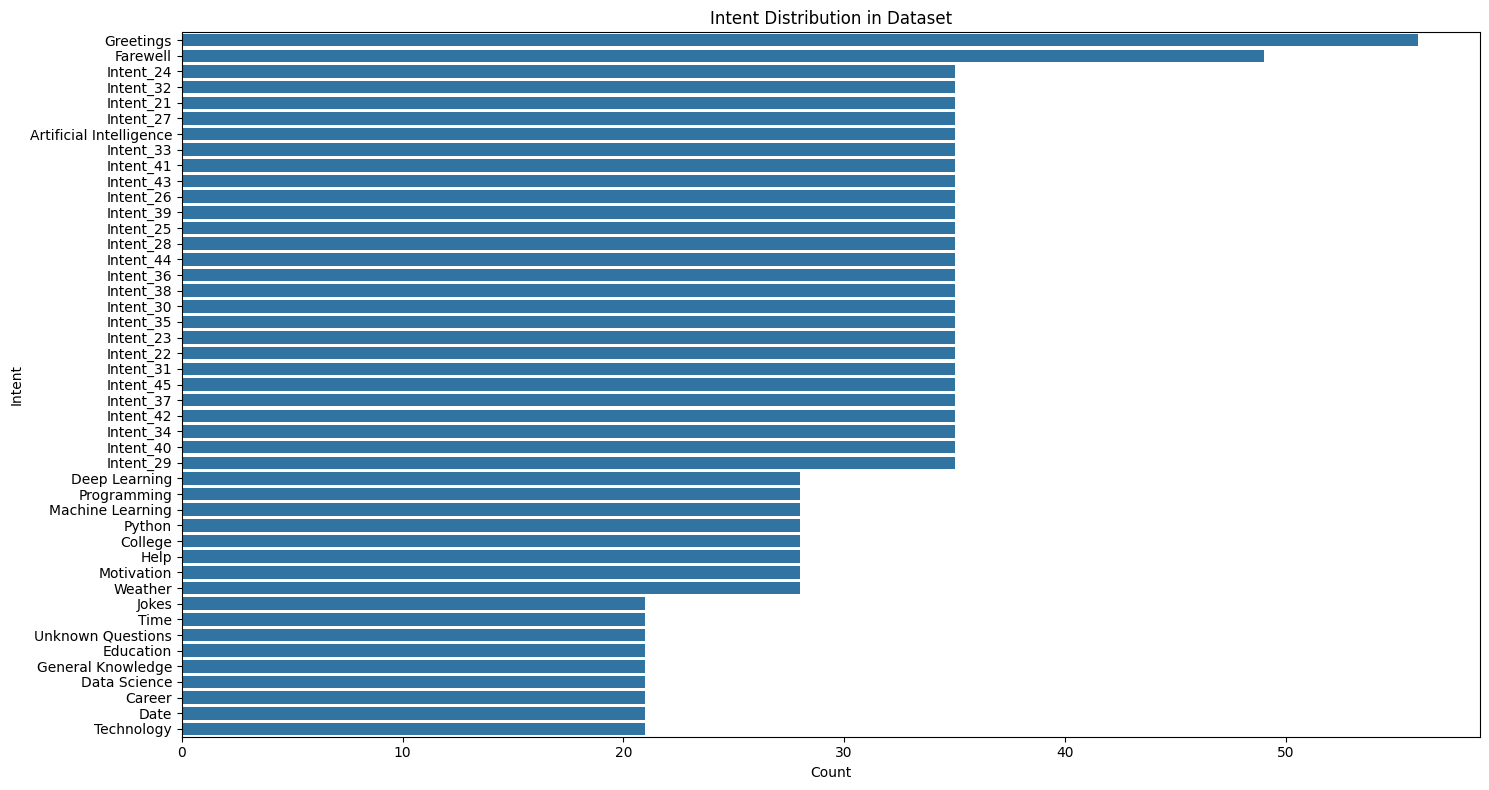


Sample Data:
                                     Question         Intent
0          what is deep learning specifically  Deep Learning
1            question one for Intent_21 today      Intent_21
2                         where is the campus        College
3                                good morning      Greetings
4                         how about Intent_24      Intent_24
5                  details on Intent_25 today      Intent_25
6                           what is Intent_32      Intent_32
7                        make me laugh please          Jokes
8  can you tell me question one for Intent_24      Intent_24
9         can you tell me how about Intent_33      Intent_33


In [8]:
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(15, 8))
sns.countplot(y='Intent', data=df, order=df['Intent'].value_counts().index)
plt.title("Intent Distribution in Dataset")
plt.xlabel("Count")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

print("\nSample Data:")
print(df.head(10))

In [9]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['Cleaned_Question'] = df['Question'].apply(clean_text)

In [10]:
label_encoder = LabelEncoder()
df['Intent_Encoded'] = label_encoder.fit_transform(df['Intent'])

X = df['Cleaned_Question']
y = df['Intent_Encoded']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=2000)
X_train_tfidf = vectorizer.fit_transform(X_train_raw).toarray()
X_test_tfidf = vectorizer.transform(X_test_raw).toarray()

In [11]:
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Support Vector Machine": SVC(probability=True)
}

ml_results = []
trained_models = {}

for name, model in ml_models.items():
    start_train = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test_tfidf)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    ml_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time
    })
    trained_models[name] = model

results_df = pd.DataFrame(ml_results)
print("Machine Learning Models Comparison:")
print(results_df.to_string(index=False))

best_ml_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
best_ml_model = trained_models[best_ml_name]
print(f"\nBest ML Model Automatically Selected: {best_ml_name}")

Machine Learning Models Comparison:
                 Model  Accuracy  Precision   Recall  F1 Score  Training Time (s)  Prediction Time (s)
   Logistic Regression  0.412587   0.414535 0.412587  0.410782           0.589037             0.000961
           Naive Bayes  0.395105   0.406697 0.395105  0.394728           0.023070             0.021133
         Decision Tree  0.412587   0.412587 0.412587  0.412587           0.083500             0.000702
         Random Forest  0.412587   0.412587 0.412587  0.412587           2.326723             0.081471
Support Vector Machine  0.412587   0.422494 0.412587  0.415680           5.741205             0.132677

Best ML Model Automatically Selected: Logistic Regression


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.0280 - loss: 3.8057 - val_accuracy: 0.0629 - val_loss: 3.8012
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.0236 - loss: 3.7958 - val_accuracy: 0.0594 - val_loss: 3.7926
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.0342 - loss: 3.7819 - val_accuracy: 0.0769 - val_loss: 3.7646
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.0464 - loss: 3.7243 - val_accuracy: 0.0559 - val_loss: 3.6411
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.0595 - loss: 3.5538 - val_accuracy: 0.0559 - val_loss: 3.3760
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.0543 - loss: 3.3986 - val_accuracy: 0.0490 - val_loss: 3.2521
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.0648 - loss: 3.2836 - val_accuracy: 0.0420 - val_loss: 3.1395
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.0639 - loss: 3.2327 - val_accuracy: 0.0874 -

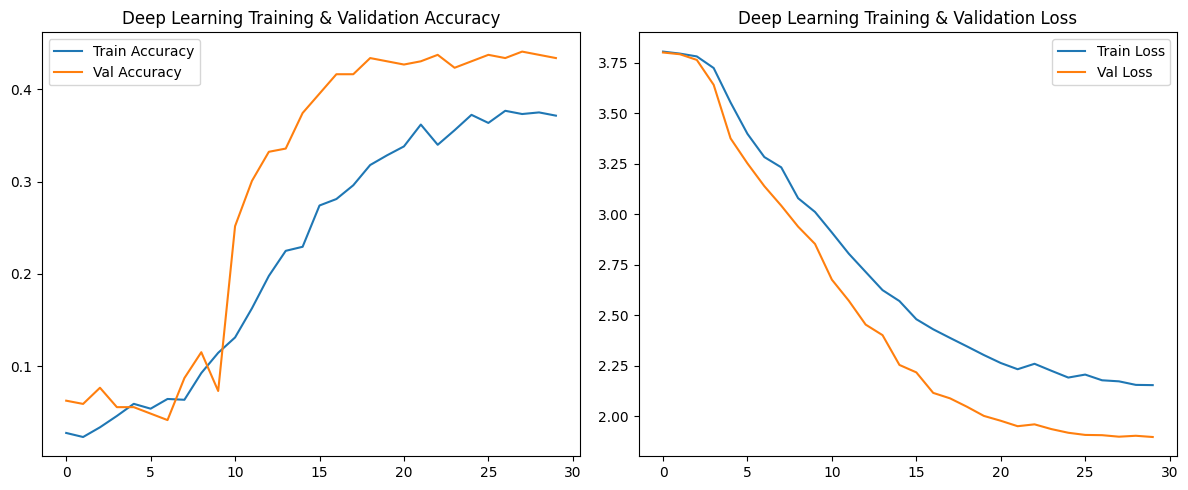

In [12]:
max_words = 2000
max_len = 20

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

num_classes = len(label_encoder.classes_)

dl_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

dl_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

start_dl_train = time.time()
history = dl_model.fit(X_train_pad, y_train, epochs=30, batch_size=32, validation_data=(X_test_pad, y_test), verbose=1)
dl_train_time = time.time() - start_dl_train

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Deep Learning Training & Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Deep Learning Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
Deep Learning Accuracy: 0.4336
Deep Learning Precision: 0.4270
Deep Learning Recall: 0.4336
Deep Learning F1 Score: 0.4274

Classification Report (Deep Learning):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         8
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00        11
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00         7
          11       0.00      0.00      0.00         7
          12       0.00      0.00      0.00        10
          13       0.00      0.00      0.0

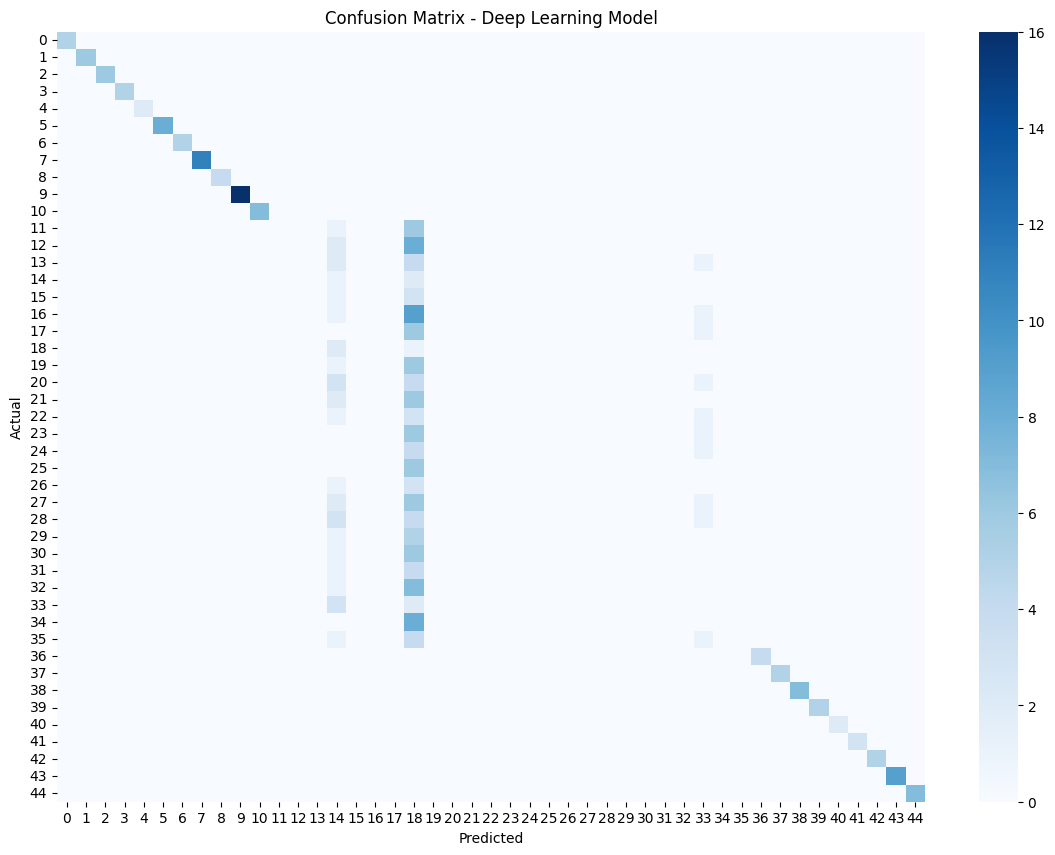

In [13]:
start_dl_pred = time.time()
dl_preds_prob = dl_model.predict(X_test_pad)
dl_pred_time = time.time() - start_dl_pred
dl_preds = np.argmax(dl_preds_prob, axis=1)

dl_acc = accuracy_score(y_test, dl_preds)
dl_prec, dl_rec, dl_f1, _ = precision_recall_fscore_support(y_test, dl_preds, average='weighted', zero_division=0)

print(f"Deep Learning Accuracy: {dl_acc:.4f}")
print(f"Deep Learning Precision: {dl_prec:.4f}")
print(f"Deep Learning Recall: {dl_rec:.4f}")
print(f"Deep Learning F1 Score: {dl_f1:.4f}")
print("\nClassification Report (Deep Learning):")
print(classification_report(y_test, dl_preds, zero_division=0))

plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, dl_preds)
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Deep Learning Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
joblib.dump(best_ml_model, "best_ml_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

dl_model.save("chatbot_dl.keras")

print("All models and preprocessing objects have been saved successfully.")

All models and preprocessing objects have been saved successfully.


In [15]:
loaded_ml_model = joblib.load("best_ml_model.pkl")
loaded_vectorizer = joblib.load("vectorizer.pkl")
loaded_label_encoder = joblib.load("label_encoder.pkl")
with open('tokenizer.pkl', 'rb') as handle:
    loaded_tokenizer = pickle.load(handle)

loaded_dl_model = load_model("chatbot_dl.keras")

print("Models loaded successfully for inference.")

Models loaded successfully for inference.


In [20]:
conversation_history = []
CONFIDENCE_THRESHOLD = 0.5

def get_dl_prediction(text):
    cleaned = clean_text(text)
    seq = loaded_tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')
    probs = loaded_dl_model.predict(pad, verbose=0)[0]
    max_idx = np.argmax(probs)
    confidence = probs[max_idx]
    intent = loaded_label_encoder.inverse_transform([max_idx])[0]
    return intent, confidence

def get_ml_prediction(text):
    cleaned = clean_text(text)
    vec = loaded_vectorizer.transform([cleaned]).toarray()
    probs = loaded_ml_model.predict_proba(vec)[0]
    max_idx = np.argmax(probs)
    confidence = probs[max_idx]
    intent = loaded_label_encoder.inverse_transform([max_idx])[0]
    return intent, confidence

def generate_response(intent):
    if intent in intents_data:
        return random.choice(intents_data[intent]["responses"])
    else:
        return "I am unable to find the correct information for that."

def chat():
    print("\n" + "="*55)
    print(" SmartAI Chatbot Module Successfully Loaded")
    print("="*55)

    # Explicit Start/Stop Boot Sequence
    while True:
        boot_command = input("\nSystem: Type 'start' to talk to the bot, or 'stop' to exit: ").strip().lower()
        if boot_command == 'start':
            print("\nBot: Hello! I am online and ready to answer your questions.")
            print("(Type 'exit' or 'stop' at any time to close the chat)\n")
            break
        elif boot_command in ['stop', 'exit']:
            print("System: Chatbot closed. You can view the performance metrics below.")
            return
        else:
            print("System: Invalid command. Please type 'start' or 'stop'.")

    # Core Chat Loop
    while True:
        user_input = input("You: ").strip()

        if user_input.lower() in ['exit', 'quit', 'stop']:
            print("Bot: Goodbye! Have a great day.")
            break

        if not user_input:
            continue

        # Get Predictions
        intent_dl, conf_dl = get_dl_prediction(user_input)

        # Fallback Logic
        if conf_dl < CONFIDENCE_THRESHOLD:
            intent_ml, conf_ml = get_ml_prediction(user_input)
            if conf_ml < CONFIDENCE_THRESHOLD:
                intent = "Unknown Questions"
                confidence = max(conf_dl, conf_ml)
                model_used = "Fallback"
            else:
                intent = intent_ml
                confidence = conf_ml
                model_used = "Machine Learning"
        else:
            intent = intent_dl
            confidence = conf_dl
            model_used = "Deep Learning"

        # Generate and Print Response
        response = generate_response(intent)
        conversation_history.append({"User": user_input, "Intent": intent})

        print(f"Bot: {response}")
        print(f"[Debug Log] Intent: {intent} | Confidence: {confidence:.2f} | Engine: {model_used}\n")

# This single line automatically triggers the chat loop when you 'Run All'
chat()


 SmartAI Chatbot Module Successfully Loaded

System: Type 'start' to talk to the bot, or 'stop' to exit: hi
System: Invalid command. Please type 'start' or 'stop'.

System: Type 'start' to talk to the bot, or 'stop' to exit: start

Bot: Hello! I am online and ready to answer your questions.
(Type 'exit' or 'stop' at any time to close the chat)

You: what ois python
Bot: Python is a high-level programming language great for AI and data science.
[Debug Log] Intent: Python | Confidence: 1.00 | Engine: Deep Learning

You: stop
Bot: Goodbye! Have a great day.


=== Performance Comparison: Machine Learning vs Deep Learning ===
                          Metric  Best ML Model  Deep Learning (Bi-LSTM)
                        Accuracy       0.412587                 0.433566
               Training Time (s)       0.589037                69.088084
Prediction Time (s) for Test Set       0.000961                 1.810523
                 Model Size (KB)      34.936523              2452.037109


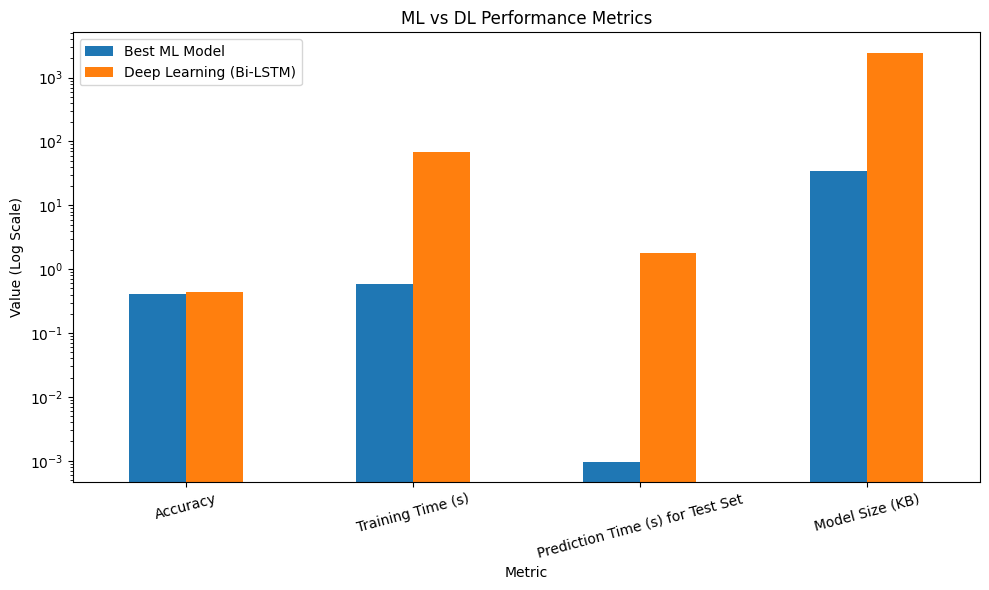

In [19]:
dl_memory = os.path.getsize("chatbot_dl.keras") / 1024
ml_memory = os.path.getsize("best_ml_model.pkl") / 1024

comparison_data = {
    "Metric": ["Accuracy", "Training Time (s)", "Prediction Time (s) for Test Set", "Model Size (KB)"],
    "Best ML Model": [
        results_df.loc[results_df['Model'] == best_ml_name, 'Accuracy'].values[0],
        results_df.loc[results_df['Model'] == best_ml_name, 'Training Time (s)'].values[0],
        results_df.loc[results_df['Model'] == best_ml_name, 'Prediction Time (s)'].values[0],
        ml_memory
    ],
    "Deep Learning (Bi-LSTM)": [
        dl_acc,
        dl_train_time,
        dl_pred_time,
        dl_memory
    ]
}

comp_df = pd.DataFrame(comparison_data)
print("=== Performance Comparison: Machine Learning vs Deep Learning ===")
print(comp_df.to_string(index=False))

comp_df.set_index("Metric").plot(kind='bar', figsize=(10, 6))
plt.title("ML vs DL Performance Metrics")
plt.ylabel("Value (Log Scale)")
plt.yscale('log')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()